# Callbacks y KerasTuner: Automatizando el Entrenamiento y la Arquitectura


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/07_callbacks_y_kerastuner.ipynb)

## Objetivos


- Entender los **Callbacks** como "agentes autónomos" que monitorean e intervienen en el ciclo de entrenamiento.
- Dominar la "Trinidad de Callbacks" de la industria: `EarlyStopping`, `ModelCheckpoint` y `ReduceLROnPlateau`.
- Diseñar **Callbacks Personalizados** para inyectar lógica de negocio o *debugging* en tiempo real.
- Introducir **KerasTuner** para la Búsqueda de Hiperparámetros (AutoML), entendiendo la diferencia entre *Random Search*, *Hyperband* y *Optimización Bayesiana*.
- **Criterio de Ingeniería:** Aprender a combinar KerasTuner con Callbacks para no desperdiciar cómputo de GPU ($$$).



## Prerrequisitos


- Dominio de la API Funcional y Secuencial de Keras.
- Entendimiento del *Overfitting* y la lectura de curvas de validación.
- Haber completado: [El Ecosistema Keras y APIs](06_ecosistema_keras_y_apis.ipynb).

---


## Configuración del Entorno


> **NOTA**: se instala `Keras Tuner` además.

In [1]:
# @title *Esta celda clona el repositorio, instala dependencias e importa utilidades*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    # Instalamos KerasTuner (no viene por defecto en todos los entornos)
    subprocess.run(["pip", "install", "-q", "keras-tuner>=1.4.0"], check=True)

    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

# Configuración Multi-backend de Keras 3
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import keras_tuner as kt
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

print(f"Keras versión: {keras.__version__}")
print(f"KerasTuner versión: {kt.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: No se detectó GPU. La búsqueda de hiperparámetros será lenta.")

Keras versión: 3.13.2
KerasTuner versión: 1.4.8
ADVERTENCIA: No se detectó GPU. La búsqueda de hiperparámetros será lenta.


## 1. La Motivación: El Problema de Conducir a Ciegas



Hasta ahora, nuestro flujo de trabajo ha sido:
1. Construir el modelo.
2. Llamar a `modelo.fit(epochs=50)`.
3. Esperar a que termine y "rezar" para que en la época 50 el modelo no esté sobreajustado (*Overfitting*).

**Analogía ultra simple:** Llamar a `.fit()` sin *Callbacks* es como pisar el acelerador de un auto a fondo, cerrar los ojos durante 50 segundos, y esperar haber llegado al destino sin chocar. Es decir, las probabilidades de que TODO salga bien... son bajas.

En el mundo real, los entrenamientos duran horas o días. Necesitamos un "piloto automático" que:
- Frene el auto si nos pasamos del destino (`EarlyStopping`).
- Guarde una copia de seguridad en su mejor momento (`ModelCheckpoint`).
- Suelte un poco el acelerador si el camino se vuelve sinuoso (`ReduceLROnPlateau`).

A estos agentes autónomos los llamamos **Callbacks**.

## 2. Los Cuatro *Callbacks* Estándar de la Industria



Un Callback es un objeto de Python que se "engancha" en puntos específicos del ciclo de vida del modelo (al inicio/fin de una época, al inicio/fin de un *batch*).

Vamos a definir un modelo base simple para clasificar ropa (Fashion MNIST) y le inyectamos los cuatro *Callbacks* más importantes de la industria simultáneamente.

De los mencionados arriba, falta "`TensorBoard`". En pocas palabras, permite monitorear en tiempo real de entrenamiento todas las métricas que nos interesan. Es especialmente útil cuando la cosa demora lo suyo, cuando estamos entrenando en paralelo varias topologías, etc. etc...

In [4]:
import datetime

# 1. Preparación de Datos
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Separamos un set de validación explícito (10.000 imágenes)
X_val, y_val = X_train[-10000:], y_train[-10000:]
X_train, y_train = X_train[:-10000], y_train[:-10000]

# 2. Función constructora del modelo base
def construir_modelo_base():
    inputs = keras.Input(shape=(28, 28))
    x = keras.layers.Flatten()(inputs)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    outputs = keras.layers.Dense(10, activation='softmax')(x)

    modelo = keras.Model(inputs, outputs)
    modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

### Configurando el Piloto Automático


In [5]:
import os

# Creamos directorios para modelos y logs
os.makedirs("modelos_guardados", exist_ok=True)
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# 1. EarlyStopping: Freno de Emergencia
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,                # Espera 8 épocas antes de rendirse
    restore_best_weights=True, # ¡CRÍTICO! Restaura los pesos de la mejor época
    verbose=1
)

# 2. ModelCheckpoint: Copia de Seguridad con Versionado
# MEJOR PRÁCTICA: Usar variables dinámicas en el nombre del archivo
ruta_modelo = "modelos_guardados/modelo_{epoch:02d}-{val_loss:.4f}.keras"

# Nota: si se usa una ruta estática, Ej.: "modelos_guardados/mejor_modelo.keras"
# el save_best_only=True, sobrescribe el archivo solamente si el modelo mejoró
model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=ruta_modelo,
    monitor='val_loss',
    save_best_only=True,  # Solo guarda si superó al modelo anterior
    verbose=1
)

# 3. ReduceLROnPlateau: Caja de Cambios
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,           # Reduce el LR al 20% de su valor actual
    patience=3,           # Si no mejora en 3 épocas, aplica la reducción
    min_lr=1e-6,          # Valor mínimo, no baja de este
    verbose=1
)

# 4. TensorBoard
tensorboard = keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,     # Guarda histogramas de pesos y activaciones cada época
    write_graph=True,     # Dibuja el grafo de la red
    update_freq='epoch'
)

# 5. Ejecución Combinada
print("Iniciando entrenamiento con Piloto Automático (Máx 50 épocas)...")
modelo = construir_modelo_base()

historia = modelo.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=[early_stopping, model_checkpoint, reduce_lr, tensorboard],
    verbose=0 # Silenciamos para ver solo los mensajes de los callbacks
)

Iniciando entrenamiento con Piloto Automático (Máx 50 épocas)...

Epoch 1: val_loss improved from None to 0.40876, saving model to modelos_guardados/modelo_01-0.4088.keras

Epoch 1: finished saving model to modelos_guardados/modelo_01-0.4088.keras

Epoch 2: val_loss improved from 0.40876 to 0.36185, saving model to modelos_guardados/modelo_02-0.3618.keras

Epoch 2: finished saving model to modelos_guardados/modelo_02-0.3618.keras

Epoch 3: val_loss improved from 0.36185 to 0.35053, saving model to modelos_guardados/modelo_03-0.3505.keras

Epoch 3: finished saving model to modelos_guardados/modelo_03-0.3505.keras

Epoch 4: val_loss improved from 0.35053 to 0.34521, saving model to modelos_guardados/modelo_04-0.3452.keras

Epoch 4: finished saving model to modelos_guardados/modelo_04-0.3452.keras

Epoch 5: val_loss did not improve from 0.34521

Epoch 6: val_loss improved from 0.34521 to 0.34087, saving model to modelos_guardados/modelo_06-0.3409.keras

Epoch 6: finished saving model to m


> **💡 PRO-TIP DE INGENIERÍA:**
> Observar la relación entre el `patience` de `ReduceLROnPlateau` (3) y el de `EarlyStopping` (8). Esto es intencional. Queremos que la red intente reducir el *Learning Rate* un par de veces para intentar salir del estancamiento *antes* de que el `EarlyStopping` decida abortar la misión por completo.

### Análisis Visual: Efecto de los *Callbacks*

Graficamos la historia del entrenamiento para ver exactamente dónde y cómo intervinieron nuestros *callbacks*:

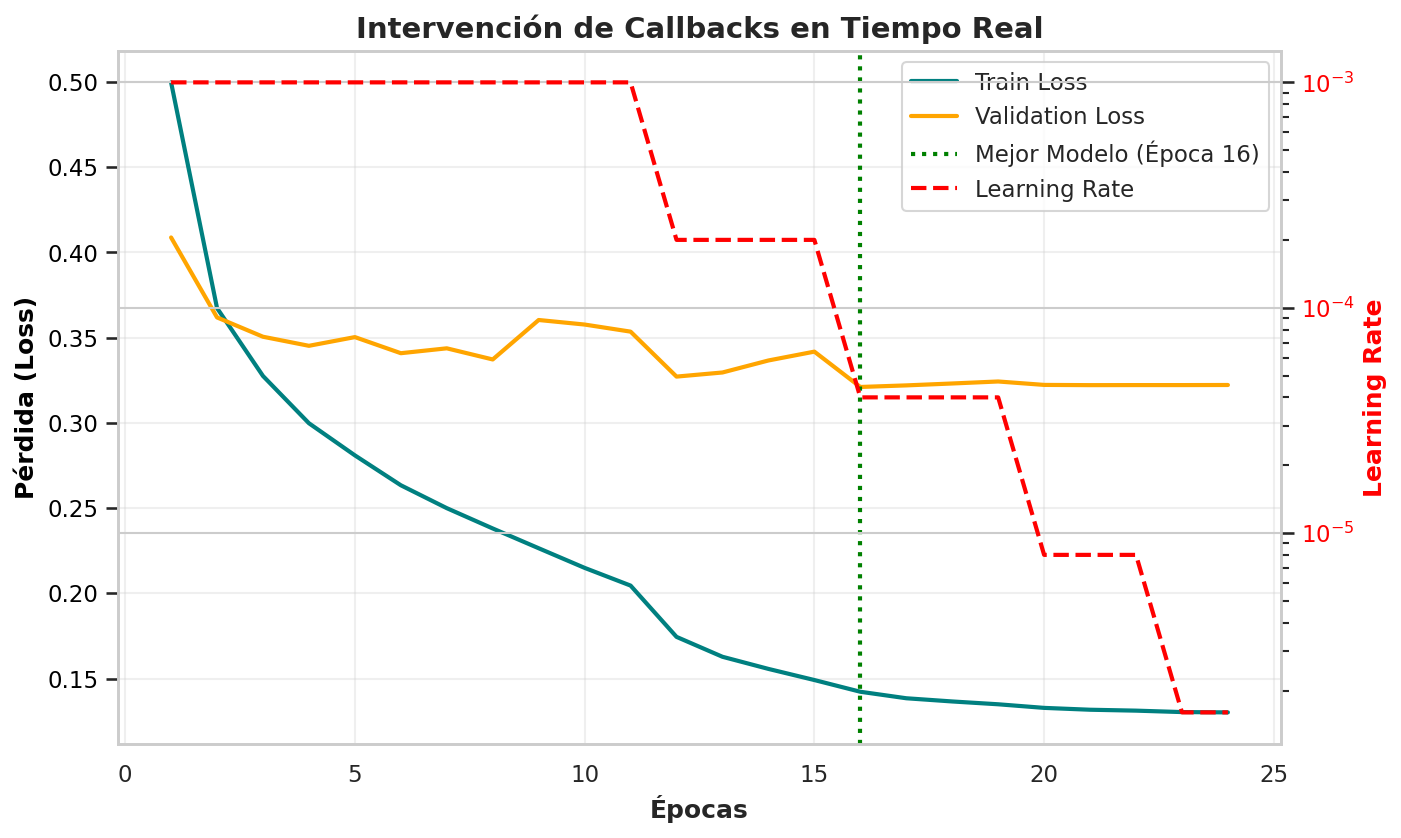

In [7]:
# Extracción de datos
loss = historia.history['loss']
val_loss = historia.history['val_loss']
lr = historia.history['learning_rate']
epocas = range(1, len(loss) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y principal (Loss)
ax1.plot(epocas, loss, 'teal', label='Train Loss', linewidth=2)
ax1.plot(epocas, val_loss, 'orange', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida (Loss)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)

# Eje Y secundario (Learning Rate)
ax2 = ax1.twinx()
ax2.plot(epocas, lr, 'red', label='Learning Rate', linestyle='--', linewidth=2)
ax2.set_ylabel('Learning Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_yscale('log') # Escala logarítmica para ver bien las caídas

# Marcamos el punto donde EarlyStopping restauró los pesos
mejor_epoca = np.argmin(val_loss) + 1
ax1.axvline(x=mejor_epoca, color='green', linestyle=':', linewidth=2, label=f'Mejor Modelo (Época {mejor_epoca})')

# Leyendas combinadas
lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()
ax1.legend(lineas_1 + lineas_2, etiquetas_1 + etiquetas_2, loc='upper right')

plt.title("Intervención de Callbacks en Tiempo Real", fontsize=14)
plt.show()

**Criterio de Ingeniería (Leyendo la Gráfica):**
1. **Caída del LR (Línea Roja Punteada):** Observar cómo el *Learning Rate* se mantiene plano hasta que el *Validation Loss* (naranja) deja de mejorar por 3 épocas. En ese momento, `ReduceLROnPlateau` entra en acción y tumba el LR. Esto suele provocar una pequeña mejora inmediata en la pérdida.
2. **Freno (Línea Verde):** El entrenamiento no llegó a las 50 épocas. `EarlyStopping` detectó que, tras 8 épocas sin superar el mínimo histórico, no valía la pena seguir gastando recursos de hardware.
3. **Restauración:** Aunque el entrenamiento terminó en una época avanzada (donde el modelo ya estaba sobreajustado), `restore_best_weights=True` nos devolvió automáticamente los pesos de la línea verde. En un entrenamiento convencional (sin *callbacks*), la red contiene los pesos del final del entrenamiento.

### Visualización Interactiva con TensorBoard en Colab

Para ver los histogramas de pesos, distribuciones y el grafo interactivo que guardó nuestro callback `TensorBoard`, podemos ejecutar este comando mágico en una celda de Colab:

In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit

> *(Nota: Descomentar las líneas en el entorno para abrir el panel interactivo).*

## 3. Callbacks Personalizados: Inyectando Lógica de Negocio



A veces, las herramientas estándar no son suficientes. ¿Qué pasa si queremos detener el entrenamiento en el momento exacto en que alcanzamos un 95% de *Accuracy* para ahorrar tiempo? ¿O si queremos enviar un mensaje a un canal de Slack/Discord cuando el modelo termina de entrenar?

Para esto, heredamos de `keras.callbacks.Callback` y sobrescribimos sus métodos (`on_epoch_end`, `on_batch_begin`, etc.).



In [9]:
class DetenerAlAlcanzarMeta(keras.callbacks.Callback):
    """
    Detiene el entrenamiento cuando se alcanza un umbral específico en una métrica.
    """
    def __init__(self, metrica='val_accuracy', umbral=0.88):
        super().__init__()
        self.metrica = metrica
        self.umbral = umbral

    def on_epoch_end(self, epoch, logs=None):
        # 'logs' es un diccionario que contiene las métricas de la época actual
        valor_actual = logs.get(self.metrica)

        if valor_actual is not None and valor_actual >= self.umbral:
            print(f"\n Época {epoch+1}: ¡Meta alcanzada! {self.metrica} llegó a {valor_actual:.4f}.")
            print("Deteniendo el entrenamiento para ahorrar cómputo.")
            self.model.stop_training = True # Esta bandera detiene el .fit()

# Probamos nuestro Callback personalizado
print("\nEntrenando con Callback Personalizado...")
modelo_custom = construir_modelo_base()
callback_meta = DetenerAlAlcanzarMeta(metrica='val_accuracy', umbral=0.88)

modelo_custom.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=[callback_meta],
    verbose=0
)


Entrenando con Callback Personalizado...

 Época 5: ¡Meta alcanzada! val_accuracy llegó a 0.8807.
Deteniendo el entrenamiento para ahorrar cómputo.


### Debugging Avanzado: Monitoreo de la Norma de los Pesos

Un problema gravísimo en redes profundas es la explosión o desvanecimiento de gradientes/pesos. Si los pesos de una capa se vuelven ceros absolutos o números gigantescos, la red muere. Vimos de forma "teórica" como evitar este tipo de problemas desde la concepción de la red, pero en tiempo de entrenamiento pueden pasar cositas...

Creamos un Callback avanzado que calcule la **Norma L2** (la magnitud) de los pesos de una capa específica al final de cada época. Si la magnitud se dispara, sabemos que tenemos un problema de inestabilidad numérica, podríamos abortar a tiempo, antes de gastar recursos en una arquitectura que ya identificamos tiene problemas.


Entrenando con Monitor de Pesos...

ALERTA: La norma de los pesos en 'capa_densa_critica' es muy alta (31.59). Posible inestabilidad.

ALERTA: La norma de los pesos en 'capa_densa_critica' es muy alta (34.17). Posible inestabilidad.


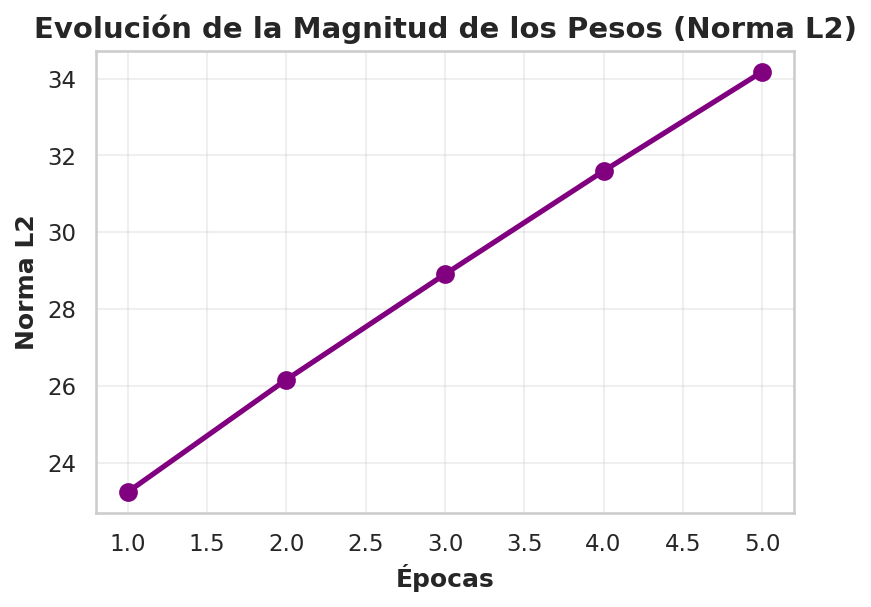

In [18]:
import keras.ops as ops

# Redefino la función original, simplemente para darle nombre a una capa de "interés"
# así la usamos para monitorear la Norma L2.

def construir_modelo_base():
    inputs = keras.Input(shape=(28, 28))
    x = keras.layers.Flatten()(inputs)
    # Apunto a monitorear la primera capa densa
    x = keras.layers.Dense(256, activation='relu', name="capa_densa_critica")(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    outputs = keras.layers.Dense(10, activation='softmax')(x)

    modelo = keras.Model(inputs, outputs)
    modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo


class MonitorNormaPesos(keras.callbacks.Callback):
    """
    Calcula y registra la Norma L2 de los pesos de una capa específica.
    Útil para detectar explosión de pesos (Weight Explosion).
    """
    def __init__(self, nombre_capa, umbral_alerta=30.0):
        super().__init__()
        self.nombre_capa = nombre_capa
        self.umbral_alerta = umbral_alerta
        self.historia_normas =[]

    def on_epoch_end(self, epoch, logs=None):
        # Buscamos la capa por su nombre
        capa = self.model.get_layer(self.nombre_capa)
        pesos = capa.get_weights()

        if pesos:
            # pesos[0] son los weights (W), pesos[1] son los biases (b)
            matriz_w = pesos[0]
            # Calculamos la Norma L2 (raíz cuadrada de la suma de los cuadrados)
            norma_l2 = np.linalg.norm(matriz_w)
            self.historia_normas.append(norma_l2)

            # Imprimimos una advertencia si los pesos están explotando
            if norma_l2 > self.umbral_alerta:
                print(f"\nALERTA: La norma de los pesos en '{self.nombre_capa}' es muy alta ({norma_l2:.2f}). Posible inestabilidad.")

# Probamos el monitor avanzado
print("\nEntrenando con Monitor de Pesos...")
modelo_debug = construir_modelo_base()

# El 30.0 va como ejemplo solamente, así se activa para nuestra red de juguete
monitor_pesos = MonitorNormaPesos(nombre_capa="capa_densa_critica", umbral_alerta=30.0)

modelo_debug.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=[monitor_pesos],
    verbose=0
)

# Visualizamos la evolución de los pesos
plt.figure(figsize=(6, 4))
plt.plot(range(1, 6), monitor_pesos.historia_normas, marker='o', color='purple')
plt.title("Evolución de la Magnitud de los Pesos (Norma L2)")
plt.xlabel("Épocas")
plt.ylabel("Norma L2")
plt.grid(True, alpha=0.3)
plt.show()

Es completamente normal que la norma de los pesos crezca de forma constante (lineal) a medida que la red aprende y los pesos se alejan de su inicialización cercana a cero.

**Criterio de Ingeniería:** Si vemos que esta gráfica crece **exponencialmente** hacia el infinito (explosión de gradientes), el *Learning Rate* es demasiado alto o falta aplicar *Batch Normalization* / *Weight Decay* (L2 Regularization). Podemos usar *callbacks* para tener *feedback* respecto a la arquitectura que estamos diseñando, de modo de "encontrar a tiempo" problemas estructurales.

## 4. KerasTuner: Automatizando la Arquitectura (AutoML)


Automatizamos el ciclo de entrenamiento, pero seguimos teniendo un problema grave: **Los Hiperparámetros**.
¿Por qué usamos 256 neuronas en la primera capa? ¿Por qué no 512? ¿Deberíamos usar Dropout? ¿Cuál es el *Learning Rate* inicial óptimo?

Probar combinaciones a mano es ineficiente. **KerasTuner** es un framework diseñado para automatizar esta búsqueda.

### "*Cheat-Sheet*" del Espacio de Búsqueda (`hp`)

Antes de construir la función, debemos entender cómo definir el espacio de búsqueda. KerasTuner provee métodos específicos según el tipo de variable matemática que queramos optimizar:

| Método | Uso Principal | Ejemplo de Código | Tip de Ingeniería |
| :--- | :--- | :--- | :--- |
| `hp.Int` | Cantidad de neuronas, capas, filtros CNN. | `hp.Int('units', min_value=32, max_value=512, step=32)` | Usar `step` para evitar que el tuner pruebe 33 neuronas, luego 34. Saltos de 32 o 64 son estándar. |
| `hp.Float` | Learning Rate, Tasa de Dropout, Regularización L2. | `hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')` | **CRÍTICO:** Usar `sampling='log'` para el Learning Rate. El tuner debe buscar en magnitudes ($10^{-4}, 10^{-3}$), no linealmente. |
| `hp.Choice` | Funciones de activación, Optimizadores. | `hp.Choice('activation', values=['relu', 'swish', 'tanh'])` | Limitar las opciones a 2 o 3 lógicas. No poner 'sigmoid' en capas ocultas si ya aprendimos que causa *Vanishing Gradient*. |
| `hp.Boolean` | Decisiones binarias (¿Usar Batch Norm? ¿Usar Dropout?). | `hp.Boolean('use_batchnorm')` | Excelente para probar si un bloque arquitectónico entero vale la pena. |

> **⚠️ LA MALDICIÓN DE LA DIMENSIONALIDAD:** No intentar tunear *absolutamente todo*. Si se tunean 20 hiperparámetros a la vez, el espacio de búsqueda será de billones de combinaciones y el Tuner jamás encontrará el óptimo. Fijar lo que sabemos que funciona (ej. optimizador Adam) y tunear solo lo crítico: **Learning Rate, Profundidad (Capas) y Anchura (Neuronas)**.

### Paso 1: La Función `build_model(hp)`


En lugar de devolver un modelo estático, creamos una función que recibe un objeto `hp` (HyperParameters). Usamos este objeto para definir rangos de búsqueda.



In [13]:
def construir_modelo_tuner(hp):
    inputs = keras.Input(shape=(28, 28))
    x = keras.layers.Flatten()(inputs)

    # 1. Tunear el número de capas ocultas (entre 1 y 3)
    for i in range(hp.Int('num_capas', min_value=1, max_value=3)):
        # 2. Tunear el número de neuronas por capa
        unidades = hp.Int(f'unidades_{i}', min_value=64, max_value=512, step=64)
        x = keras.layers.Dense(unidades, activation='relu')(x)

        # 3. Tunear si usamos Dropout o no
        if hp.Boolean(f'usar_dropout_{i}'):
            # Si usamos, tunear la tasa de dropout
            tasa = hp.Float(f'tasa_dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
            x = keras.layers.Dropout(tasa)(x)

    outputs = keras.layers.Dense(10, activation='softmax')(x)
    modelo = keras.Model(inputs, outputs)

    # 4. Tunear el Learning Rate (Escala logarítmica es VITAL aquí)
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

### Paso 2: Elegir el Algoritmo de Búsqueda (El Tuner)



| Algoritmo | Cómo funciona | Cuándo usarlo |
| :--- | :--- | :--- |
| **RandomSearch** | Prueba combinaciones al azar. | Espacios de búsqueda pequeños. Buen *baseline*. |
| **Hyperband** | Entrena muchos modelos por 1 o 2 épocas. Descarta la mitad inferior. Entrena a los sobrevivientes más tiempo. Repite. | **El Estándar.** Extremadamente eficiente en tiempo y recursos. |
| **BayesianOptimization** | Usa estadística para predecir qué combinación funcionará mejor basándose en los intentos anteriores. | Espacios de búsqueda complejos donde cada entrenamiento es muy costoso. |

Vamos a usar **Hyperband**, ya que es el más eficiente para Deep Learning.



In [14]:
# Instanciamos el Tuner
tuner = kt.Hyperband(
    construir_modelo_tuner,
    objective='val_accuracy',
    max_epochs=15,          # Épocas máximas que entrenará el mejor modelo
    factor=3,               # Factor de reducción (descarta 2/3 de los modelos en cada ronda)
    directory='tuner_logs', # Carpeta para guardar los resultados
    project_name='fashion_mnist_tuning',
    overwrite=True          # Sobrescribe búsquedas anteriores (útil en tutoriales)
)

tuner.search_space_summary()

Search space summary
Default search space size: 4
num_capas (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
unidades_0 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 512, 'step': 64, 'sampling': 'linear'}
usar_dropout_0 (Boolean)
{'default': False, 'conditions': []}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


### Paso 3: Ejecutar la Búsqueda (Integración con *Callbacks*)



> **⚠️ EL ERROR DE LOS 10.000 DÓLARES:**
> Si lanzamos un Tuner en la nube sin pasarle un *callback* de `EarlyStopping`, el Tuner entrenará combinaciones de hiperparámetros horribles (que no aprenden nada) durante todas las épocas máximas, desperdiciando horas de GPU. **Siempre combinar KerasTuner con EarlyStopping.**



In [15]:
# Definimos un EarlyStopping agresivo para la búsqueda
stop_temprano_tuner = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("\nIniciando Búsqueda de Hiperparámetros (Hyperband)...")
# La sintaxis de search() es idéntica a fit()
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128, # Usamos un batch grande para iterar rápido
    callbacks=[stop_temprano_tuner],
    verbose=1
)

Trial 30 Complete [00h 01m 12s]
val_accuracy: 0.8913000226020813

Best val_accuracy So Far: 0.8913000226020813
Total elapsed time: 00h 12m 31s


### Paso 4: Recuperar el Mejor Modelo



Una vez finalizada la búsqueda, no necesitamos reentrenar desde cero. KerasTuner guarda los mejores modelos y sus hiperparámetros.



In [16]:
# 1. Ver los mejores hiperparámetros encontrados
mejores_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n Mejores Hiperparámetros Encontrados:")
print(f"- Número de capas: {mejores_hps.get('num_capas')}")
print(f"- Learning Rate: {mejores_hps.get('learning_rate'):.5f}")

# 2. Extraer el mejor modelo ya entrenado
mejor_modelo = tuner.get_best_models(num_models=1)[0]

# 3. Evaluar en el Test Set (Datos nunca antes vistos)
loss_test, acc_test = mejor_modelo.evaluate(X_test, y_test, verbose=0)
print(f"\n Rendimiento Final en Test Set: {acc_test:.4f}")


 Mejores Hiperparámetros Encontrados:
- Número de capas: 2
- Learning Rate: 0.00038

 Rendimiento Final en Test Set: 0.8830


### Flujo de Trabajo Recomendado en la Industria (MLOps)

Lanzar un Tuner a ciegas sobre un dataset de 100 GB es un suicidio financiero en la nube, usar adecuadamente el hardware también es importante. El flujo de trabajo profesional es iterativo:

1. **Baseline Manual:** Construir un modelo simple a mano. Asegurar que el código compila, los datos fluyen y la red es capaz de aprender (supera el rendimiento aleatorio).
2. **Búsqueda Gruesa (*Coarse Search*):** Usar `Hyperband` con un subconjunto de los datos (ej. 20%) y rangos de búsqueda muy amplios (ej. LR de $10^{-5}$ a $10^{-1}$). El objetivo no es encontrar el modelo perfecto, sino ver en qué "zona" están los buenos hiperparámetros.
3. **Búsqueda Fina (*Fine Search*):** Usar `RandomSearch` o `BayesianOptimization` con el dataset completo, pero acotando los rangos alrededor de los mejores valores encontrados en el paso 2 (ej. LR de $10^{-4}$ a $10^{-3}$).
4. **Entrenamiento Final:** Una vez que el Tuner da los mejores hiperparámetros, **no usar el modelo que devuelve el Tuner directamente para producción**. Reconstruir el modelo desde cero con esos hiperparámetros y entrenarlo con el dataset completo (Train + Validation combinados) usando `EarlyStopping` y un Test Set separado para la evaluación final.

## 5. El Peligro Oculto: *Validation Overfitting*



Al usar KerasTuner, evaluamos cientos de combinaciones de hiperparámetros contra nuestro **Validation Set**.
Matemáticamente, utilizamos el Validation Set para "guiar" la arquitectura del modelo. Esto significa que **nuestro modelo se ha sobreajustado indirectamente a los datos de validación**.

Si reportamos el *Accuracy* de validación como la métrica final a algún jefe o cliente, estaríamos mintiendo (*sobran papers en dónde caen en este error*). El rendimiento real en producción será menor.
**Por eso es absolutamente crítico mantener un Test Set bloqueado bajo llave**, que el Tuner jamás vea, y usarlo únicamente en la celda final del proyecto (como hicimos en el Paso 4).

## Conexiones y Próximos Pasos



Completamos el ciclo de MLOps para arquitecturas estándar. Sabemos construir, diagnosticar, automatizar el entrenamiento y buscar la arquitectura óptima.

Hasta ahora, trabajamos con datos estructurados o imágenes pequeñas (28x28) que podemos aplanar en un vector unidimensional. Pero, ¿qué pasa si queremos procesar imágenes de alta resolución (4K) donde la posición espacial de los píxeles importa? Aplanar una imagen (`Flatten()`) destruye su estructura 2D.

- ➡️ **Siguiente:** Entramos al mundo de las arquitecturas especializadas con el notebook [Redes Convolucionales (CNN)](09_redes_convolucionales_cnn.ipynb), aprendemos cómo la IA "ve" el mundo extrayendo características espaciales jerárquicas, revolucionando la visión por computadora.
- 🔄 **Relacionado:** Si interesa el aprendizaje no supervisado (utilizando lo visto hasta este punto), el notebook [Autoencoders y Espacio Latente](08_autoencoders_y_espacio_latente.ipynb) aborda cómo usar estas mismas redes densas para comprimir información y detectar anomalías.

## Referencias


### Artículos Fundacionales

1. **Li, L., Jamieson, K., DeSalvo, G., Rostamizadeh, A., & Talwalkar, A. (2017)**. *Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization*. Journal of Machine Learning Research.  
   [[arXiv]](https://arxiv.org/abs/1603.06560) (Base teórica de Hyperband).

2. **Chollet, F. (2021)**. *Deep Learning with Python, Second Edition*. Manning Publications. (Capítulo sobre *Callbacks* y *Hyperparameter Tuning*).

### Documentación Oficial

- [Keras Callbacks API](https://keras.io/api/callbacks/)
- [KerasTuner Documentation](https://keras.io/guides/keras_tuner/)
- [TensorBoard Callback](https://keras.io/api/callbacks/tensorboard/)

### Recursos Adicionales

- **Smith, L. N. (2018)**. *A disciplined approach to neural network hyper-parameters*. arXiv.
- **Goodfellow et al. (2016)**. *Deep Learning* (Capítulo 11: Practical Methodology).
- Keras Team — Ejemplos oficiales de KerasTuner. [*Getting started with KerasTuner*](https://keras.io/keras_tuner/getting_started/)

---


## Entorno de Ejecución


In [17]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
OpenSSL,24.2.1
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
astunparse,1.6.3
attr,26.1.0
